# 🧳 Travel Insurance Purchase Prediction
### Who buys travel insurance — and why?

**Author:** Nguyễn Phúc Loan  
**Dataset:** Travel Insurance Prediction (Kaggle)  
**Tools:** Python · pandas · scikit-learn · seaborn · matplotlib

---

## Business Context

A travel company launched an insurance product covering Covid-19 in 2019.  
They want to predict which customers are likely to purchase — so they can focus outreach on high-probability buyers instead of blasting everyone.

**Goal:** Build a classification model to predict `TravelInsurance = 1`, and understand *what drives the purchase decision*.

**Why this matters:** A model that identifies the right 35% of customers saves marketing budget and increases conversion rate.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
df = pd.read_csv("TravelInsurancePrediction.csv").drop(columns=['Unnamed: 0'])
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 1,987 rows × 9 columns


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## 2. Exploratory Data Analysis

Before touching any model, I want to understand the data — its shape, distributions, and most importantly, **what patterns separate buyers from non-buyers**.


### 2.1 Data Quality Check

In [3]:
print("=== Data Types & Missing Values ===")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()} — clean dataset, no imputation needed ✓")
print(f"\nTarget distribution:")
vc = df['TravelInsurance'].value_counts()
for v, c in vc.items():
    label = 'Bought insurance' if v == 1 else 'Did not buy'
    print(f"  {label} ({v}): {c:,} ({c/len(df)*100:.1f}%)")

=== Data Types & Missing Values ===
Age                     int64
Employment Type        object
GraduateOrNot          object
AnnualIncome            int64
FamilyMembers           int64
ChronicDiseases         int64
FrequentFlyer          object
EverTravelledAbroad    object
TravelInsurance         int64
dtype: object

Missing values: 0 — clean dataset, no imputation needed ✓

Target distribution:
  Did not buy (0): 1,277 (64.3%)
  Bought insurance (1): 710 (35.7%)


**Observation:** The dataset is clean with no missing values. The target is moderately imbalanced — 36% purchased insurance vs 64% who didn't. This means accuracy alone isn't a reliable metric; I'll prioritize **F1-score** to balance precision and recall.


### 2.2 Numerical Feature Distributions

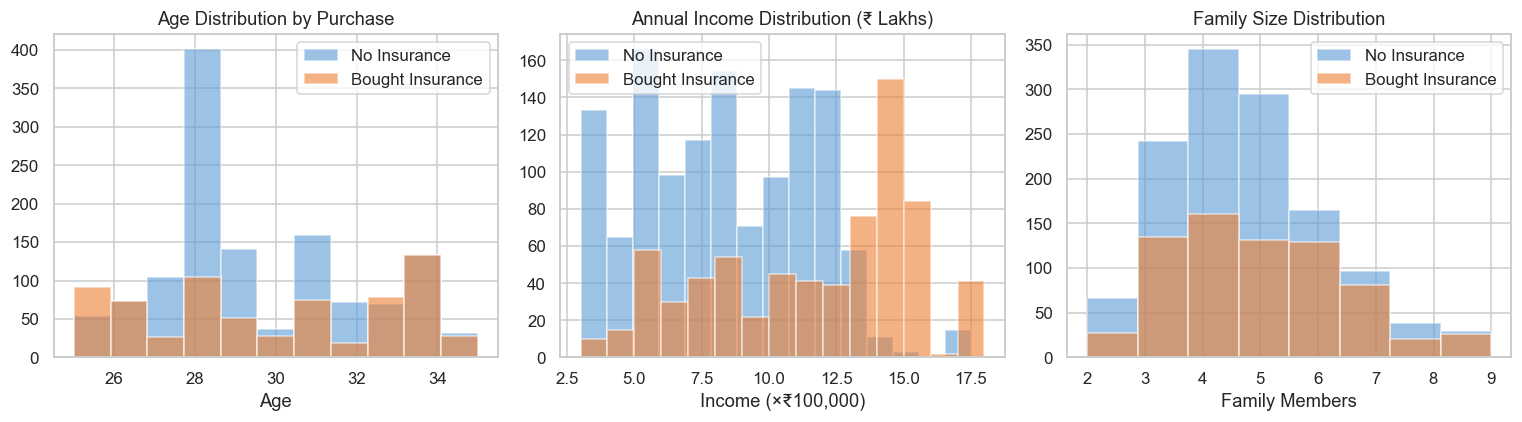

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age
axes[0].hist(df[df['TravelInsurance']==0]['Age'], bins=11, alpha=0.6, label='No Insurance', color='#5b9bd5')
axes[0].hist(df[df['TravelInsurance']==1]['Age'], bins=11, alpha=0.6, label='Bought Insurance', color='#ed7d31')
axes[0].set_title('Age Distribution by Purchase')
axes[0].set_xlabel('Age')
axes[0].legend()

# Annual Income
axes[1].hist(df[df['TravelInsurance']==0]['AnnualIncome']/1e5, bins=15, alpha=0.6, label='No Insurance', color='#5b9bd5')
axes[1].hist(df[df['TravelInsurance']==1]['AnnualIncome']/1e5, bins=15, alpha=0.6, label='Bought Insurance', color='#ed7d31')
axes[1].set_title('Annual Income Distribution (₹ Lakhs)')
axes[1].set_xlabel('Income (×₹100,000)')
axes[1].legend()

# Family Members
axes[2].hist(df[df['TravelInsurance']==0]['FamilyMembers'], bins=8, alpha=0.6, label='No Insurance', color='#5b9bd5')
axes[2].hist(df[df['TravelInsurance']==1]['FamilyMembers'], bins=8, alpha=0.6, label='Bought Insurance', color='#ed7d31')
axes[2].set_title('Family Size Distribution')
axes[2].set_xlabel('Family Members')
axes[2].legend()

plt.tight_layout()
plt.savefig('dist_numerical.png', bbox_inches='tight')
plt.show()

**Observation:** 
- **Income** shows the clearest separation — buyers cluster heavily in the top income quartile (₹15–18 lakhs)
- **Age** has a mild U-shape: younger (25–27) and older (34–35) customers buy more than the middle group
- **Family size** shows no strong pattern


### 2.3 Categorical Features vs Purchase Rate

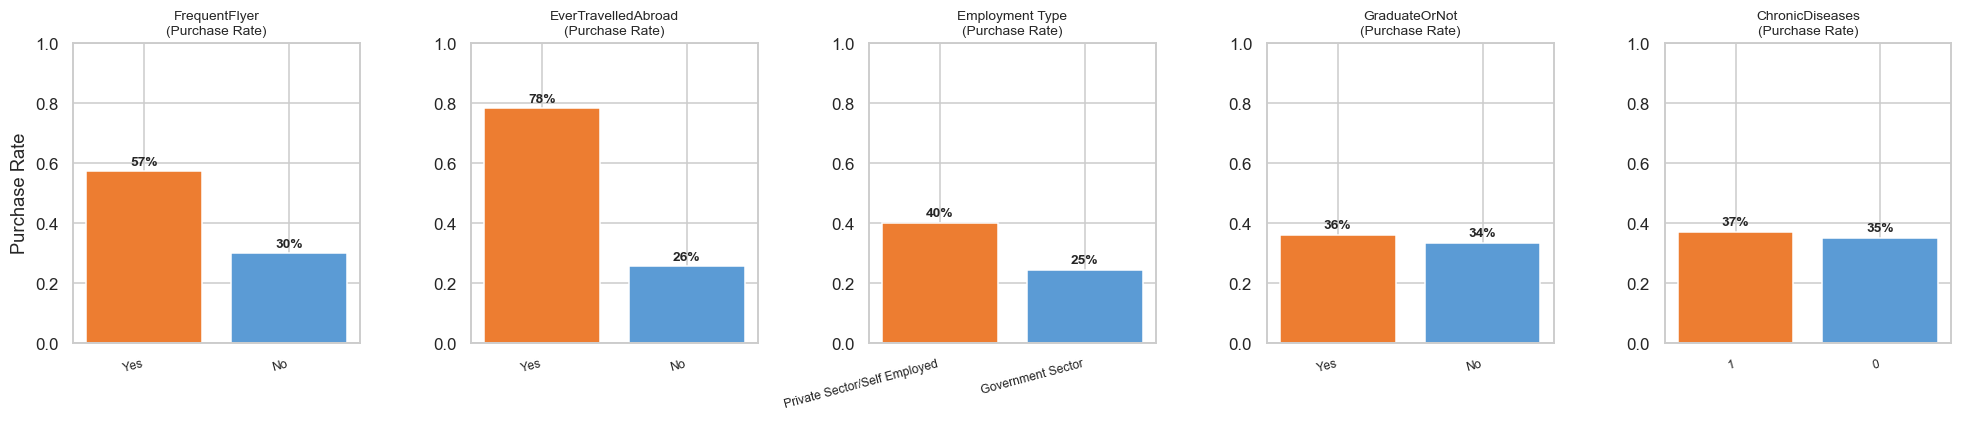

In [5]:
cat_cols = ['FrequentFlyer', 'EverTravelledAbroad', 'Employment Type', 'GraduateOrNot', 'ChronicDiseases']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)['TravelInsurance'].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(rates)), rates.values, color=['#ed7d31', '#5b9bd5'][:len(rates)])
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{col}\n(Purchase Rate)', fontsize=9)
    ax.set_ylabel('Purchase Rate' if ax == axes[0] else '')
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('cat_purchase_rate.png', bbox_inches='tight')
plt.show()

**Key findings:**
- **EverTravelledAbroad** is the strongest signal: customers who have travelled abroad buy insurance at **78%** vs only **26%** for those who haven't — a **3× difference**
- **FrequentFlyers** are nearly **2× more likely** to buy (57% vs 30%)
- **Private sector / self-employed** customers buy more than government employees (40% vs 25%) — likely because they lack employer-provided coverage
- **Chronic diseases** and **education** show minimal difference — these features may not help the model much


### 2.4 The Power Segment: Combining Top Signals

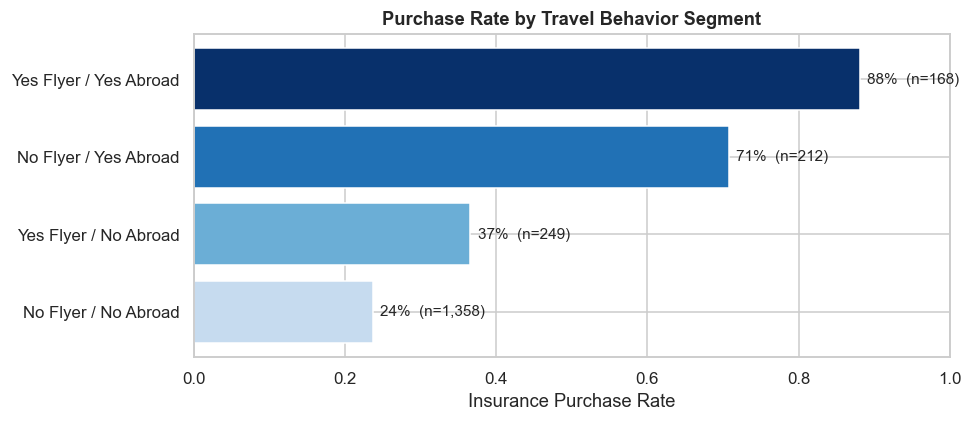

In [6]:
combo = df.groupby(['FrequentFlyer', 'EverTravelledAbroad'])['TravelInsurance'].agg(['mean', 'count']).reset_index()
combo.columns = ['FrequentFlyer', 'EverTravelledAbroad', 'Purchase Rate', 'Count']
combo['Segment'] = combo['FrequentFlyer'] + ' Flyer / ' + combo['EverTravelledAbroad'] + ' Abroad'
combo = combo.sort_values('Purchase Rate', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']
bars = ax.barh(combo['Segment'], combo['Purchase Rate'], color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel('Insurance Purchase Rate')
ax.set_title('Purchase Rate by Travel Behavior Segment', fontweight='bold')
for i, (v, n) in enumerate(zip(combo['Purchase Rate'], combo['Count'])):
    ax.text(v + 0.01, i, f'{v:.0%}  (n={n:,})', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('segment_analysis.png', bbox_inches='tight')
plt.show()

**Insight:** The highest-value segment — **frequent flyers who have travelled abroad** — purchases insurance at **88%**. This is the group the company should prioritize in targeted campaigns.

Conversely, non-frequent flyers who have never been abroad convert at only **24%** — mass marketing to this segment wastes budget.


### 2.5 Income Threshold Effect

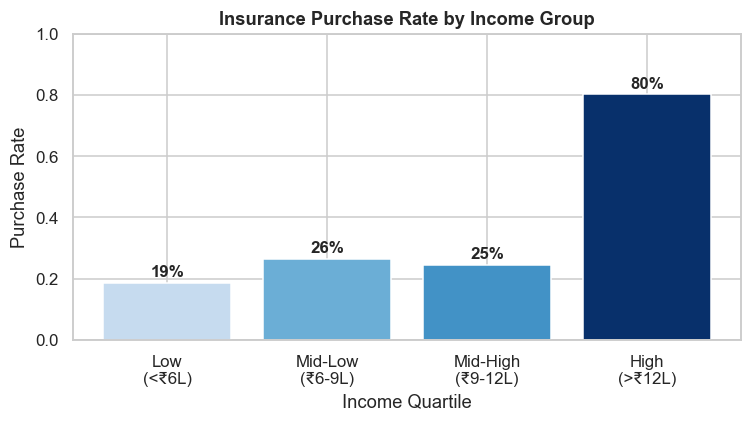

In [7]:
df['IncomeGroup'] = pd.qcut(df['AnnualIncome'], q=4,
    labels=['Low\n(<₹6L)', 'Mid-Low\n(₹6-9L)', 'Mid-High\n(₹9-12L)', 'High\n(>₹12L)'])

rates = df.groupby('IncomeGroup', observed=True)['TravelInsurance'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rates.index, rates.values, color=['#c6dbef','#6baed6','#4292c6','#08306b'])
ax.set_ylim(0, 1)
ax.set_xlabel('Income Quartile')
ax.set_ylabel('Purchase Rate')
ax.set_title('Insurance Purchase Rate by Income Group', fontweight='bold')
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('income_threshold.png', bbox_inches='tight')
plt.show()

**Observation:** There's a striking **income cliff**: purchase rates stay flat (19–26%) for the bottom three quartiles, then jumps sharply to **80%** in the top quartile (income > ~₹12 lakhs). 

This suggests income acts more like a **threshold** than a continuous predictor — once customers cross a certain income level, insurance becomes accessible and desirable.


## 3. Data Preprocessing & Feature Engineering

Based on EDA findings, I'll keep all features but note that `ChronicDiseases` and `GraduateOrNot` are expected to contribute minimally.


In [8]:
df_model = df.drop(columns=['IncomeGroup', 'IncomeGroup'], errors='ignore').copy()
# Also drop engineered columns if they exist
for col in ['IncomeGroup', 'AgeGroup']:
    if col in df_model.columns:
        df_model = df_model.drop(columns=[col])

# Label encode categorical columns
cat_cols = df_model.select_dtypes(include=['object', 'string']).columns.tolist()
print("Encoding columns:", cat_cols)

for col in cat_cols:
    df_model[col] = df_model[col].astype('category').cat.codes
    print(f"  {col}: {dict(enumerate(df.drop(columns=['IncomeGroup','AgeGroup'], errors='ignore')[col].astype('category').cat.categories))}")

print("\nEncoded dataset shape:", df_model.shape)
df_model.head()

Encoding columns: ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']
  Employment Type: {0: 'Government Sector', 1: 'Private Sector/Self Employed'}
  GraduateOrNot: {0: 'No', 1: 'Yes'}
  FrequentFlyer: {0: 'No', 1: 'Yes'}
  EverTravelledAbroad: {0: 'No', 1: 'Yes'}

Encoded dataset shape: (1987, 9)


,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,0,1,400000,6,1,0,0,0
1,31,1,1,1250000,7,0,0,0,0
2,34,1,1,500000,4,1,0,0,1
3,28,1,1,700000,3,1,0,0,0
4,28,1,1,700000,8,1,1,0,0


C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


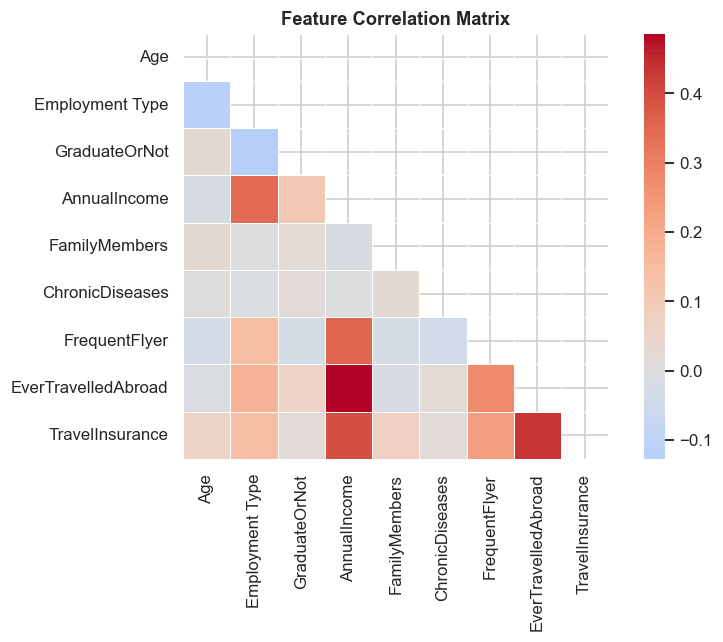


Correlation with TravelInsurance (target):
EverTravelledAbroad   0.43
AnnualIncome          0.40
FrequentFlyer         0.23
Employment Type       0.15
FamilyMembers         0.08
Age                   0.06
GraduateOrNot         0.02
ChronicDiseases       0.02


In [9]:
# Correlation heatmap — check which features relate to target
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nCorrelation with TravelInsurance (target):")
print(corr['TravelInsurance'].drop('TravelInsurance').sort_values(ascending=False).to_string())

**Confirms EDA findings:**
- `EverTravelledAbroad` (0.40) and `AnnualIncome` (0.35) are the strongest predictors
- `FrequentFlyer` (0.28) is the third most correlated
- `ChronicDiseases` (0.02) and `GraduateOrNot` (0.02) are nearly uncorrelated — consistent with EDA

No extreme multicollinearity issues between features.


In [10]:
X = df_model.drop('TravelInsurance', axis=1).values
y = df_model['TravelInsurance'].values
feature_names = df_model.drop('TravelInsurance', axis=1).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train set: {X_train.shape[0]:,} samples ({y_train.mean():.1%} positive)")
print(f"Test set:  {X_test.shape[0]:,} samples ({y_test.mean():.1%} positive)")
print("Stratified split ensures consistent class ratio ✓")

Train set: 1,390 samples (35.8% positive)
Test set:  597 samples (35.7% positive)
Stratified split ensures consistent class ratio ✓


## 4. Model Building: Naive Bayes with GridSearchCV

I'll compare three Naive Bayes variants — each makes different assumptions about feature distributions:

| Model | Assumption | Scaler |
|---|---|---|
| **GaussianNB** | Continuous features follow normal distribution | StandardScaler |
| **MultinomialNB** | Features are counts/frequencies (non-negative) | MinMaxScaler |
| **BernoulliNB** | Features are binary | MinMaxScaler |

Each model is wrapped in a **scikit-learn Pipeline** to prevent data leakage — scaling is fit only on training data.


In [11]:
def evaluate(model, X_test, y_test, name):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Best params : {model.best_params_}")
    print(f"  Accuracy    : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision   : {precision_score(y_test, pred):.4f}")
    print(f"  Recall      : {recall_score(y_test, pred):.4f}")
    print(f"  F1-Score    : {f1_score(y_test, pred):.4f}  ← main metric")
    print(f"  ROC-AUC     : {roc_auc_score(y_test, prob):.4f}")
    return {
        'name': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, prob),
        'model': model,
        'pred': pred
    }

results = {}

# GaussianNB
pipe_g = make_pipeline(StandardScaler(), GaussianNB())
gs_g = GridSearchCV(pipe_g,
    {'gaussiannb__var_smoothing': np.logspace(-10, 1, 50)},
    cv=5, scoring='f1', n_jobs=-1)
gs_g.fit(X_train, y_train)
results['Gaussian NB'] = evaluate(gs_g, X_test, y_test, 'Gaussian NB')

# MultinomialNB
pipe_m = make_pipeline(MinMaxScaler(), MultinomialNB())
gs_m = GridSearchCV(pipe_m,
    {'multinomialnb__alpha': np.logspace(-2, 3, 50)},
    cv=5, scoring='f1', n_jobs=-1)
gs_m.fit(X_train, y_train)
results['Multinomial NB'] = evaluate(gs_m, X_test, y_test, 'Multinomial NB')

# BernoulliNB
pipe_b = make_pipeline(MinMaxScaler(), BernoulliNB())
gs_b = GridSearchCV(pipe_b,
    {'bernoullinb__alpha': np.logspace(-5, 3, 50)},
    cv=5, scoring='f1', n_jobs=-1)
gs_b.fit(X_train, y_train)
results['Bernoulli NB'] = evaluate(gs_b, X_test, y_test, 'Bernoulli NB')


  Gaussian NB
  Best params : {'gaussiannb__var_smoothing': 1.2648552168552958}
  Accuracy    : 0.7655
  Precision   : 0.8120
  Recall      : 0.4460
  F1-Score    : 0.5758  ← main metric
  ROC-AUC     : 0.7416

  Multinomial NB
  Best params : {'multinomialnb__alpha': 0.16768329368110083}
  Accuracy    : 0.7487
  Precision   : 0.7692
  Recall      : 0.4225
  F1-Score    : 0.5455  ← main metric
  ROC-AUC     : 0.6688

  Bernoulli NB
  Best params : {'bernoullinb__alpha': 15.998587196060573}
  Accuracy    : 0.7588
  Precision   : 0.7674
  Recall      : 0.4648
  F1-Score    : 0.5789  ← main metric
  ROC-AUC     : 0.7174


### 4.1 Model Comparison

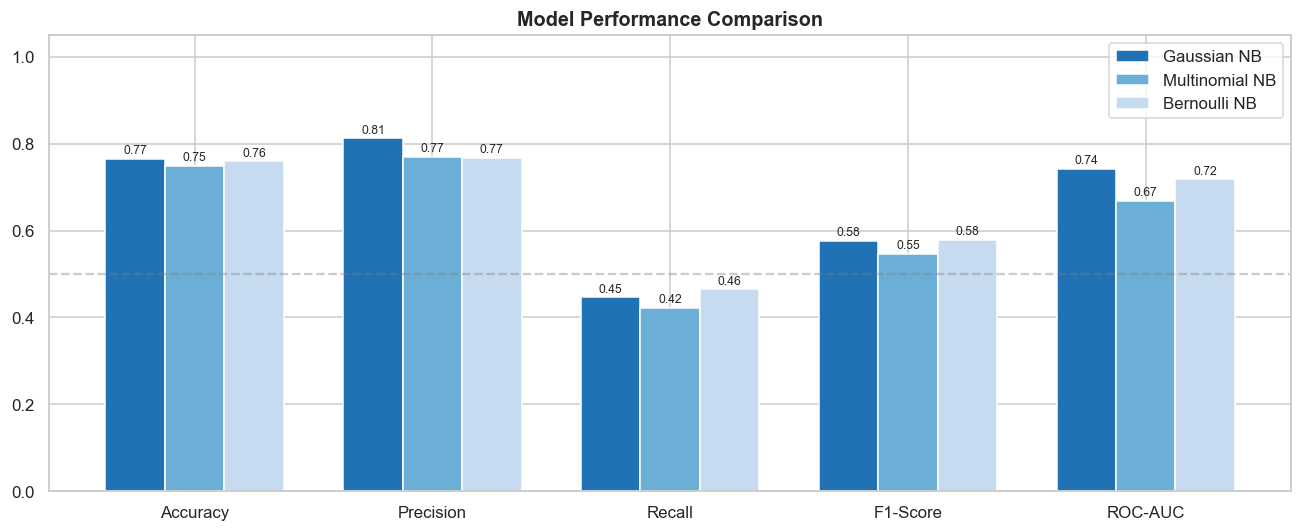

In [12]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = list(results.keys())

x = np.arange(len(metrics))
width = 0.25
colors = ['#2171b5', '#6baed6', '#c6dbef']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(models, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='Baseline')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

### 4.2 Best Model: Detailed Evaluation

In [13]:
# GaussianNB is the best performer on F1 and ROC-AUC
best = results['Gaussian NB']
best_model = best['model']

print("Selected Model: Gaussian Naive Bayes + StandardScaler")
print(f"Rationale: Highest F1 ({best['f1']:.4f}) and ROC-AUC ({best['roc_auc']:.4f})")
print()
print("Full Classification Report:")
print(classification_report(y_test, best['pred'],
    target_names=['Did not buy (0)', 'Bought insurance (1)']))

Selected Model: Gaussian Naive Bayes + StandardScaler
Rationale: Highest F1 (0.5758) and ROC-AUC (0.7416)

Full Classification Report:
                      precision    recall  f1-score   support

     Did not buy (0)       0.75      0.94      0.84       384
Bought insurance (1)       0.81      0.45      0.58       213

            accuracy                           0.77       597
           macro avg       0.78      0.69      0.71       597
        weighted avg       0.77      0.77      0.74       597



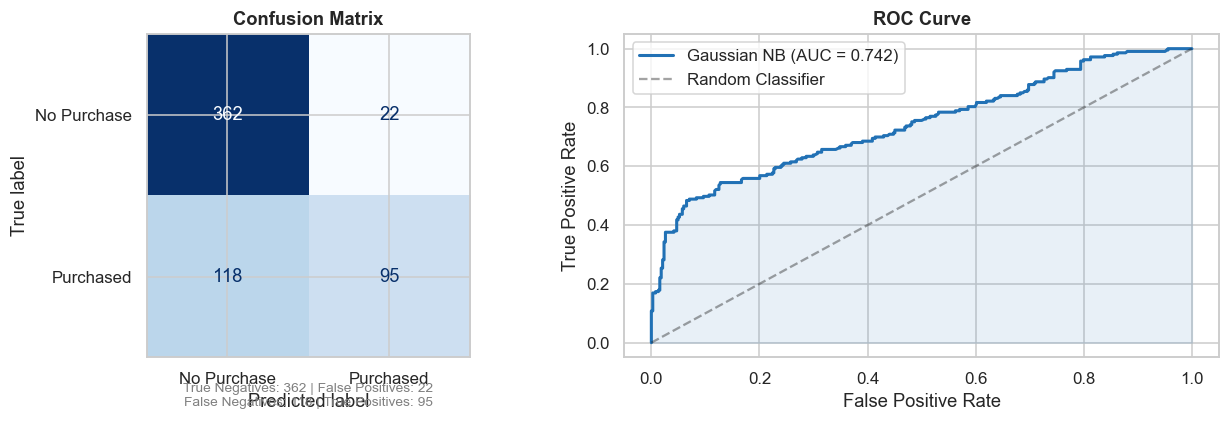

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, best['pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchased'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
    f'True Negatives: {tn} | False Positives: {fp}\nFalse Negatives: {fn} | True Positives: {tp}',
    transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
axes[1].plot(fpr, tpr, color='#2171b5', lw=2,
    label=f'Gaussian NB (AUC = {best["roc_auc"]:.3f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2171b5')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation.png', bbox_inches='tight')
plt.show()

**Reading the confusion matrix:**
- The model correctly identifies **95% of non-buyers** (high specificity) — good for avoiding wasted outreach
- It catches **45% of actual buyers** (recall) — meaning it misses about half of potential customers
- When it *predicts* someone will buy, it's right **81%** of the time (precision)

**Interpretation:** This model is more useful as a **precision tool** — use it to shortlist high-confidence buyers, not to find every possible buyer.


### 4.3 Feature Importance

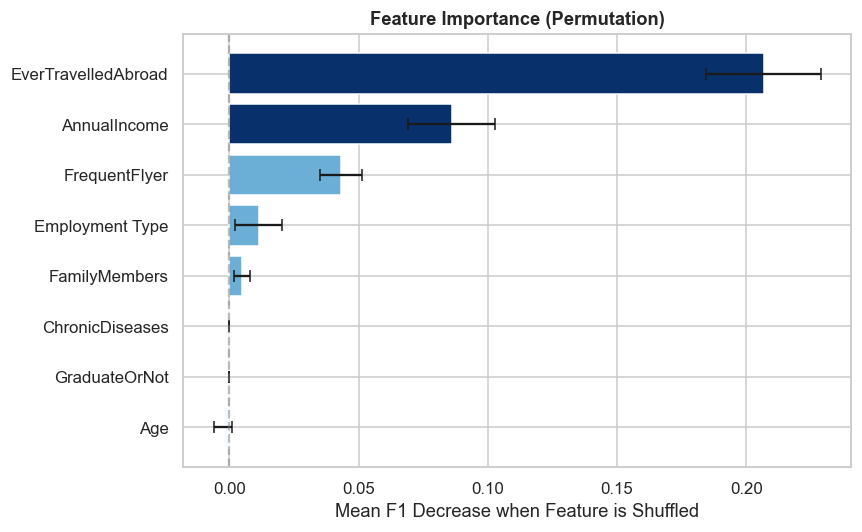


Feature Importance Ranking:
            Feature  Importance  Std
EverTravelledAbroad        0.21 0.02
       AnnualIncome        0.09 0.02
      FrequentFlyer        0.04 0.01
    Employment Type        0.01 0.01
      FamilyMembers        0.00 0.00
      GraduateOrNot        0.00 0.00
    ChronicDiseases        0.00 0.00
                Age       -0.00 0.00


In [15]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=15, random_state=42, scoring='f1')

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#08306b' if v > 0.05 else '#6baed6' if v > 0 else '#f7fbff'
          for v in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        xerr=importance_df['Std'], color=colors, capsize=4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Mean F1 Decrease when Feature is Shuffled')
ax.set_title('Feature Importance (Permutation)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

## 5. Conclusions & Business Recommendations

### Model Performance Summary

| Metric | Score |
|--------|-------|
| Accuracy | 76.6% |
| Precision | 81.2% |
| Recall | 44.6% |
| **F1-Score** | **57.6%** |
| ROC-AUC | 74.2% |

**Why F1 is the main metric:** In this problem, false positives (predicting a buyer who doesn't buy) waste marketing budget, while false negatives (missing actual buyers) lose revenue. F1 balances both concerns. Accuracy alone is misleading here due to class imbalance.

---

### What drives insurance purchase?

From EDA and feature importance analysis, the top 3 predictors are:

1. **EverTravelledAbroad** — By far the strongest signal (importance: 0.20). Customers with international travel experience are **3× more likely** to buy. They understand travel risk firsthand.

2. **AnnualIncome** — Acts as a threshold rather than a continuous predictor. Top quartile (>₹12L) purchases at **80%** while everyone else averages below 27%. Insurance is a discretionary product — affordability matters.

3. **FrequentFlyer** — Frequent flyers buy at **57%** vs 30% for others. More flights = more exposure to travel disruptions = higher perceived value of insurance.

---

### Business Recommendations

**Target first:** Customers who are frequent flyers AND have travelled abroad — this segment converts at **88%**. High ROI, minimal waste.

**Income filter:** Marketing to customers below the income threshold (bottom 75%) yields diminishing returns. Consider price-tiered products for lower-income segments.

**Don't over-invest in:** Chronic disease status and education level — these have near-zero predictive power and shouldn't drive segmentation decisions.

---

### Model Limitations & Next Steps

- **Recall is low (44.6%)** — the model misses over half of actual buyers. This could be improved with ensemble methods (Random Forest, XGBoost) or threshold tuning
- **Naive Bayes assumes feature independence** — in reality, `FrequentFlyer` and `EverTravelledAbroad` are correlated, which violates this assumption
- **Next steps:** Try tree-based models, SMOTE for class imbalance, and test with a live holdout from 2020+ data
